In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('Tourism Quantity Data.csv')
df['Continente'] = df['Continente'].fillna('NA')

### 1 Distribuição e concentração do turismo global

#### **Teste 1: Receitas concentradas nos Top 10 países**

● H0: os Top 10 países não concentram a maior parte das receitas globais de turismo.

● H1: os Top 10 países concentram a maior parte das receitas globais de turismo.

Calulamos a soma das receitas dos top 10 no período (2004-2018) e comparamos com a distribuição nula

Participação REAL dos Top 10: 51.33%
P-Valor Simulado: 0.0000


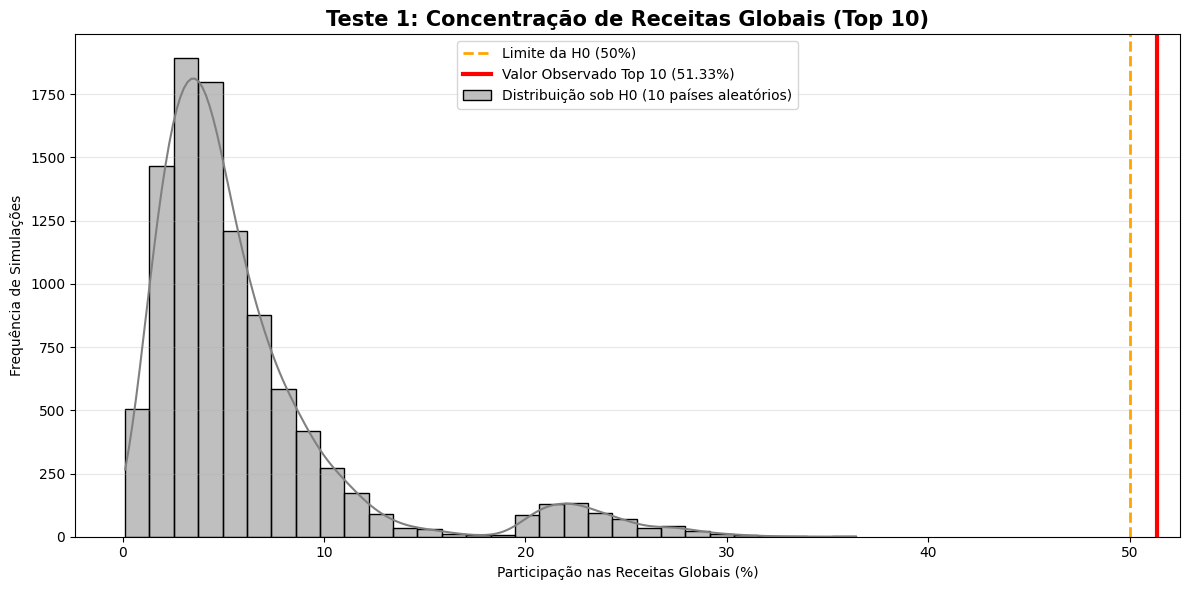

In [51]:
df_pais = df.groupby('País')['Receipts'].sum().reset_index()
total_global = df_pais['Receipts'].sum()

# Valor observado
top10_real = df_pais.nlargest(10, 'Receipts')['Receipts'].sum()
share_observado = (top10_real / total_global) * 100

print(f"Participação REAL dos Top 10: {share_observado:.2f}%")

#np.random.seed(42) # Para o resultado ser o mesmo toda vez que rodar

# sorteando 10 países 10 mil vezes para plotar a distribuição.
simulacoes = 10000
resultados_h0 = []
for _ in range(simulacoes):
    amostra_10 = df_pais.sample(10)['Receipts'].sum()
    share_amostra = (amostra_10 / total_global) * 100
    resultados_h0.append(share_amostra)

p_valor = np.sum(np.array(resultados_h0) >= share_observado) / simulacoes

print(f"P-Valor Simulado: {p_valor:.4f}")

# 5. Plotando a Distribuição
plt.figure(figsize=(12, 6))
sns.histplot(resultados_h0, bins=30, kde=True, color='gray', alpha=0.5, label='Distribuição sob H0 (10 países aleatórios)')
plt.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='Limite da H0 (50%)')
plt.axvline(x=share_observado, color='red', linestyle='-', linewidth=3, label=f'Valor Observado Top 10 ({share_observado:.2f}%)')

plt.title('Teste 1: Concentração de Receitas Globais (Top 10)', fontsize=15, fontweight='bold')
plt.xlabel('Participação nas Receitas Globais (%)')
plt.ylabel('Frequência de Simulações')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

A análise estatística levou à rejeição da hipótese nula ($H_0$), mostrando que a ideia de que as receitas do turismo mundial não estariam concentradas nos dez principais destinos globais não se sustenta. Com isso, a hipótese alternativa ($H_1$) tem forte indicio de ser verdadeira, indicando que esse grupo seleto de países realmente concentra a maior parte do faturamento mundial do setor. Além disso, o p-valor extremamente baixo mostra que essa diferença dificilmente aconteceu por acaso, reforçando que essa concentração é uma característica estrutural do mercado turístico, dominado por poucas potências econômicas.

#### **Teste 2: Diferença entre continentes**

● H0: os continentes têm participação semelhante em arrivals e receipts.

● H1: alguns continentes têm participação maior que outros em arrivals e receipts.

Para o Teste 2, a métrica de comparação será a Variância. Se os continentes tivessem participações semelhantes (como a $H_0$ sugere), a diferença entre eles seria pequena, resultando em uma variância próxima de zero.

Participação Real (Receitas %):
Continente
AF     4.21
AS    30.65
EU    35.72
NA    20.31
OC     3.98
SA     5.13
Name: Receipts, dtype: float64

P-Valor Simulado: 0.1729


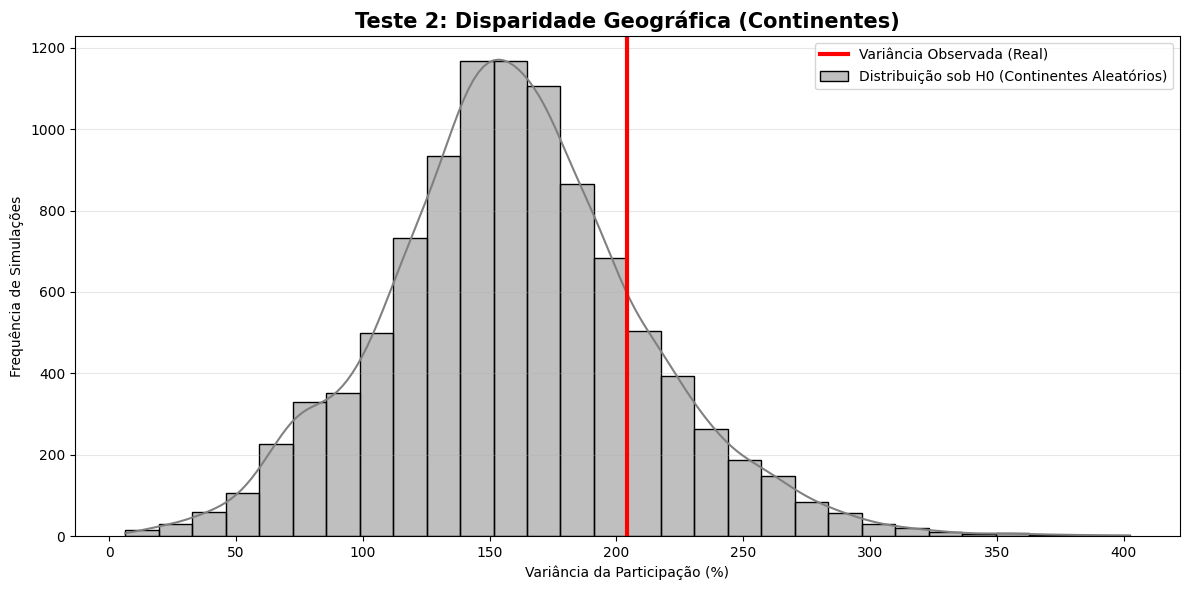

In [52]:
df_cont = df.groupby(['País', 'Continente'])[['Arrivals', 'Receipts']].mean().reset_index()

# Valor observado, participação do continentes
total_receipts = df_cont['Receipts'].sum()
share_real = (df_cont.groupby('Continente')['Receipts'].sum() / total_receipts) * 100
var_observada = share_real.var()

print(f"Participação Real (Receitas %):\n{share_real.round(2)}\n")

# simulaões da H0
simulacoes = 10000
variancias_h0 = []
for _ in range(simulacoes):
    # embaralhando os continentes
    shuffled_continentes = np.random.permutation(df_cont['Continente'].values)
    #recalculando a participação com continentes embaralhados
    temp_df = pd.DataFrame({'Continente_Falso': shuffled_continentes, 'Receipts': df_cont['Receipts'].values})
    share_simulado = (temp_df.groupby('Continente_Falso')['Receipts'].sum() / total_receipts) * 100
    variancias_h0.append(share_simulado.var())

p_valor = np.sum(np.array(variancias_h0) >= var_observada) / simulacoes
print(f"P-Valor Simulado: {p_valor:.4f}")

# 5. Plotando a Distribuição
plt.figure(figsize=(12, 6))
sns.histplot(variancias_h0, bins=30, kde=True, color='gray', alpha=0.5, label='Distribuição sob H0 (Continentes Aleatórios)')
plt.axvline(x=var_observada, color='red', linestyle='-', linewidth=3, label=f'Variância Observada (Real)')
plt.title('Teste 2: Disparidade Geográfica (Continentes)', fontsize=15, fontweight='bold')
plt.xlabel('Variância da Participação (%)')
plt.ylabel('Frequência de Simulações')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Com um p-valor proximo de 0,17, o teste mostrou que não há evidências suficientes para rejeitar a hipótese nula ($H_0$). Apesar de Europa e Ásia concentrarem grandes parcelas da receita global do turismo, 35,72% e 30,65%, respectivamente, essa diferença não foi forte o bastante, do ponto de vista estatístico, para indicar que ela necessariamente foge do que poderia acontecer ao acaso dentro da distribuição atual dos dados. Isso sugere que a concentração das receitas parece estar mais relacionada ao peso econômico e turístico de alguns países específicos, como observado no Teste 1, do que propriamente a uma vantagem continental da Europa ou da Ásia como um todo.

#### **Teste 3: Diferença entre grupos de renda**

● H0: países de diferentes IncomeGroups têm níveis semelhantes de turismo.

● H1: países de diferentes IncomeGroups apresentam níveis diferentes de turismo.

Vamos usar a Variância das Médias de cada grupo. Se a renda não importasse ($H_0$), as médias seriam parecidas e a variância seria baixa.

Média Real de Receitas por Grupo (US$):
IncomeGroup
High income            1.280867e+10
Upper middle income    4.348146e+09
Lower middle income    1.855249e+09
Low income             4.511041e+08
Name: Receipts, dtype: float64

P-Valor Simulado: 0.0499


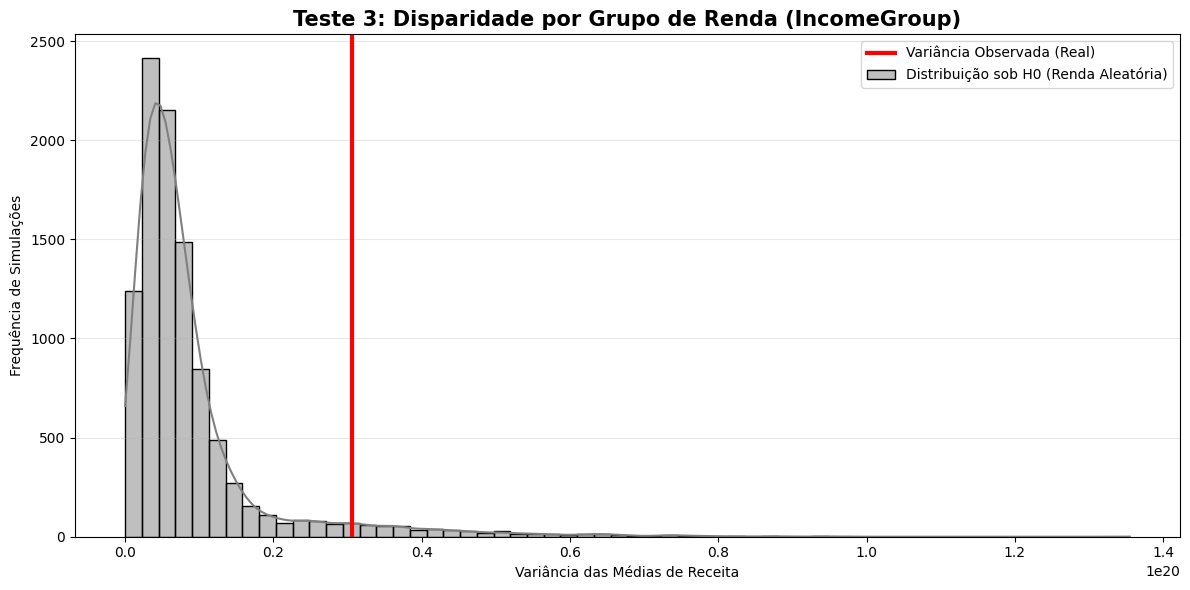

In [53]:
df_income = df.groupby(['País', 'IncomeGroup'])['Receipts'].mean().reset_index()

# Valor Observado: Variância das médias de Receita entre os grupos de renda
medias_reais = df_income.groupby('IncomeGroup')['Receipts'].mean()
var_observada = medias_reais.var()

print(f"Média Real de Receitas por Grupo (US$):\n{medias_reais.sort_values(ascending=False)}\n")

# Simulação da Hipótese Nula (H0)
simulacoes = 10000
variancias_h0 = []
for _ in range(simulacoes):
    # Embaralhamos os grupos de renda
    shuffled_income = np.random.permutation(df_income['IncomeGroup'].values)
    # Recalculamos as médias com os grupos falsos/embaralhados
    temp_df = pd.DataFrame({'Income_Falso': shuffled_income, 'Receipts': df_income['Receipts'].values})
    medias_simuladas = temp_df.groupby('Income_Falso')['Receipts'].mean()
    variancias_h0.append(medias_simuladas.var())

p_valor = np.sum(np.array(variancias_h0) >= var_observada) / simulacoes
print(f"P-Valor Simulado: {p_valor:.4f}")

# 5. Plotando a Distribuição
plt.figure(figsize=(12, 6))
sns.histplot(variancias_h0, bins=60, kde=True, color='gray', alpha=0.5, label='Distribuição sob H0 (Renda Aleatória)')
plt.axvline(x=var_observada, color='red', linestyle='-', linewidth=3, label=f'Variância Observada (Real)')
plt.title('Teste 3: Disparidade por Grupo de Renda (IncomeGroup)', fontsize=15, fontweight='bold')
plt.xlabel('Variância das Médias de Receita')
plt.ylabel('Frequência de Simulações')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Com um p-valor de 0,0489, o teste apresentou significância estatística, já que o resultado ficou abaixo do limite de 0,05. Isso levou a rejeição da hipótese nula ($H_0$), indicando que o nível de renda de um país realmente influencia seu desempenho no turismo. Os dados mostram que países classificados como de alta renda (High income) possuem uma média de faturamento turístico muito maior do que países de baixa renda (Low income). Dessa forma, a hipótese alternativa ($H_1$) foi confirmada, reforçando que fatores como infraestrutura, desenvolvimento econômico e capacidade de investimento estão diretamente relacionados à geração de receita no turismo mundial.

### **1.2 Eficiência, crescimento e dependência econômica**

#### **Teste 1: Mais turistas geram mais receita**

● H0: países com mais arrivals não têm necessariamente mais receipts.

● H1: países com mais arrivals tendem a ter mais receipts.

A métrica usada foi Correlação. Sob a $H_0$ (hipótese nula), a correlação seria próxima de zero (embaralhar os dados de receita não mudaria nada).Sob a $H_1$, a correlação real será muito mais alta do que qualquer cenário aleatório.


Correlação Real Observada (r): 0.7568

P-Valor Simulado: 0.0000


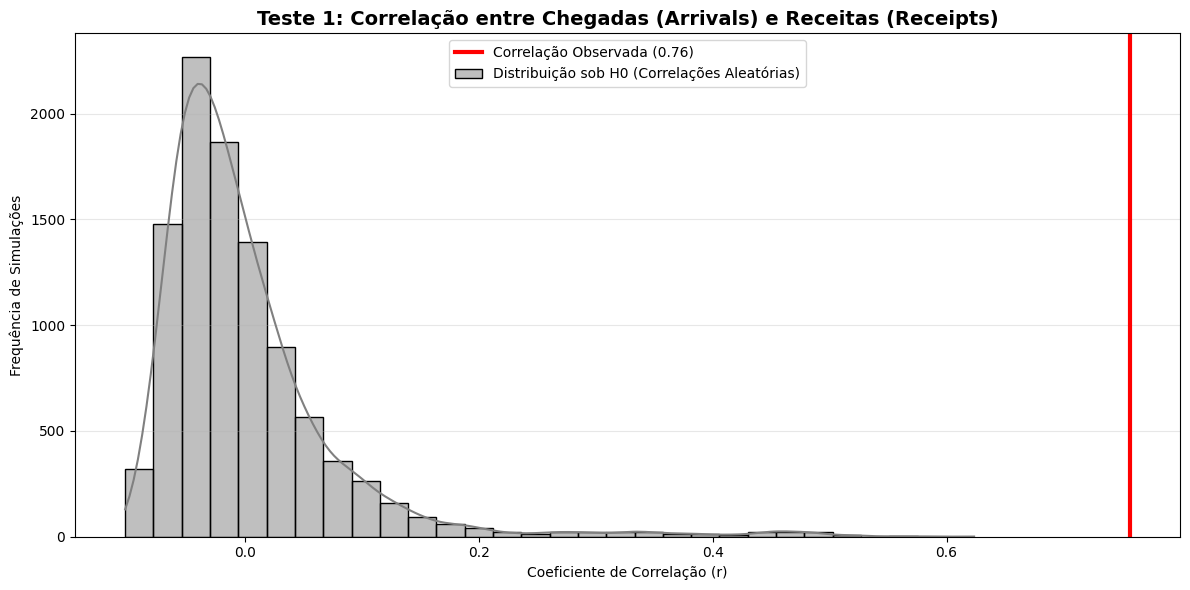

In [54]:
df_relacao = df.groupby('País')[['Arrivals', 'Receipts']].mean().dropna()

# valor observado correlação de pearson
corr_real, _ = pearsonr(df_relacao['Arrivals'], df_relacao['Receipts'])
print(f"Correlação Real Observada (r): {corr_real:.4f}\n")

# simulação da Hipótese Nula (H0)
simulacoes = 10000
correlacoes_h0 = []

arrivals_array = df_relacao['Arrivals'].values
receipts_array = df_relacao['Receipts'].values

for _ in range(simulacoes):
    # Embaralhamos apenas as receitas (destruindo a relação real com os arrivals)
    shuffled_receipts = np.random.permutation(receipts_array)
    # Calculamos a correlação desse cenario
    r_simulado, _ = pearsonr(arrivals_array, shuffled_receipts)
    correlacoes_h0.append(r_simulado)

p_valor = np.sum(np.array(correlacoes_h0) >= corr_real) / simulacoes
print(f"P-Valor Simulado: {p_valor:.4f}")

# 5. Plotando a Distribuição
plt.figure(figsize=(12, 6))
sns.histplot(correlacoes_h0, bins=30, kde=True, color='gray', alpha=0.5, label='Distribuição sob H0 (Correlações Aleatórias)')
plt.axvline(x=corr_real, color='red', linestyle='-', linewidth=3, label=f'Correlação Observada ({corr_real:.2f})')
plt.title('Teste 1: Correlação entre Chegadas (Arrivals) e Receitas (Receipts)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlação (r)')
plt.ylabel('Frequência de Simulações')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Rejeita-se a hipótese nula H0. O p-valor observado é extremamente baixo, isso demonstra que a probabilidade de a correlação observada entre chegadas e receitas ser fruto do acaso é praticamente nula. Isso confirma estatisticamente que o volume de turistas é um preditor da receita gerada, validando a tendência de que o crescimento no fluxo de visitantes se traduz diretamente em ganho financeiro para as nações analisadas. 

#### **Teste 2: Receita por turista varia entre grupos de renda**

● H0: a receita por turista é parecida entre os IncomeGroups.

● H1: a receita por turista muda conforme o IncomeGroup.

Usando a variância também.

Receita Média por Turista por Grupo (US$):
IncomeGroup
High income            1131.32
Lower middle income     887.83
Upper middle income     868.22
Low income              621.38
Name: Rec_por_Turista, dtype: float64

P-Valor Simulado: 0.1540


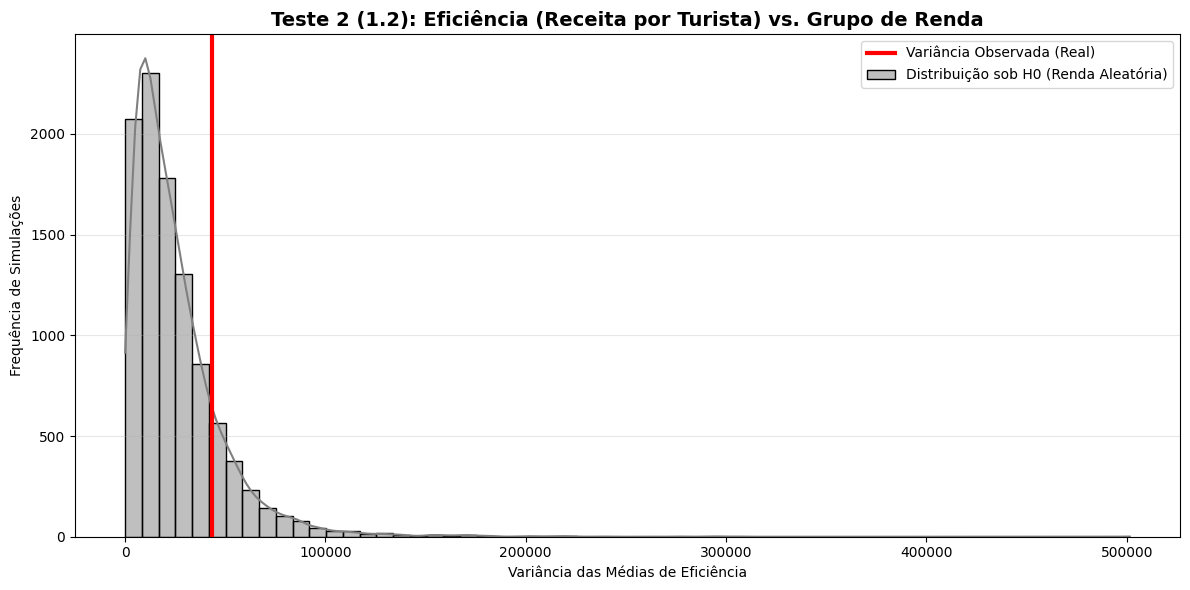

In [55]:
df_eff = df.groupby(['País', 'IncomeGroup'])[['Arrivals', 'Receipts']].mean().reset_index()

# receita por turista
df_eff['Rec_por_Turista'] = df_eff['Receipts'] / df_eff['Arrivals']

# Valor Observado: Variância das médias de Receita por Turista entre os grupos
medias_reais = df_eff.groupby('IncomeGroup')['Rec_por_Turista'].mean()
var_observada = medias_reais.var()

print(f"Receita Média por Turista por Grupo (US$):\n{medias_reais.sort_values(ascending=False).round(2)}\n")

# 4. Simulação da Hipótese Nula (H0)
simulacoes = 10000
variancias_h0 = []

valores_eficiencia = df_eff['Rec_por_Turista'].values
grupos_renda = df_eff['IncomeGroup'].values

for _ in range(simulacoes):
    # embaralha os grupos de renda
    shuffled_income = np.random.permutation(grupos_renda)
    # recalcula as médias com os grupos embaralhados
    temp_df = pd.DataFrame({'Income_Falso': shuffled_income, 'Rec_por_Turista': valores_eficiencia})
    medias_simuladas = temp_df.groupby('Income_Falso')['Rec_por_Turista'].mean()
    # guardando a variância desse cenário aleatório
    variancias_h0.append(medias_simuladas.var())

p_valor = np.sum(np.array(variancias_h0) >= var_observada) / simulacoes
print(f"P-Valor Simulado: {p_valor:.4f}")

# 6. Plotando a Distribuição
plt.figure(figsize=(12, 6))
sns.histplot(variancias_h0, bins=60, kde=True, color='gray', alpha=0.5, label='Distribuição sob H0 (Renda Aleatória)')
plt.axvline(x=var_observada, color='red', linestyle='-', linewidth=3, label=f'Variância Observada (Real)')
plt.title('Teste 2 (1.2): Eficiência (Receita por Turista) vs. Grupo de Renda', fontsize=14, fontweight='bold')
plt.xlabel('Variância das Médias de Eficiência')
plt.ylabel('Frequência de Simulações')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Não se rejeita a hipótese nula ($H_0$). Com um $p$-valor proximo de 0,15 (acima do limite padrão de 0,05), não há evidência estatística suficiente para afirmar que a receita média por turista varia significativamente entre os diferentes grupos de renda (IncomeGroups). Embora países de alta renda apresentem volumes totais de receita muito superiores, o gasto médio individual de cada turista não demonstrou uma disparidade estrutural clara neste dataset. Isso sugere que a "eficiência" de captura de divisas por visitante pode ser influenciada por fatores que vão além da classificação econômica do país, como custo de vida local, tipo de turismo praticado ou duração da estadia.